#### Acoustic Quality and Variance Assessment

Extracts F0, Energy, and Duration from generated .wav files to mathematically prove conditional acoustic variance.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import librosa
import numpy as np
from tqdm import tqdm
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed

def _process_single_audio(filepath):
    try:
        # Load audio (original behavior: native sample rate)
        y, sr = librosa.load(filepath, sr=None)
        # 1. Duration Analysis
        duration = librosa.get_duration(y=y, sr=sr)
        # 2. Energy Variance (Root Mean Square)
        rms = librosa.feature.rms(y=y)[0]
        mean_energy = np.mean(rms)
        # 3. Fundamental Frequency (F0) Extraction using pYIN algorithm (original behavior)
        # fmin=50Hz (deep male), fmax=500Hz (high female)
        f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
        # Filter out unvoiced frames (silence/consonants) to get true pitch
        valid_f0 = f0[~np.isnan(f0)]
        mean_pitch = np.mean(valid_f0) if len(valid_f0) > 0 else 0
        pitch_std = np.std(valid_f0) if len(valid_f0) > 0 else 0
        return {
            "Filename": os.path.basename(filepath),
            "Duration (s)": duration,
            "Mean Energy (RMS)": mean_energy,
            "Mean Pitch (Hz)": mean_pitch,
            "Pitch Variance (Std)": pitch_std
        }
    except Exception as e:
        # Catch errors gracefully without crashing the entire multiprocessing pool
        print(f"Error processing {filepath}: {e}")
        return None

def evaluate_acoustic_variance(audio_dir, sample_limit=2500, max_workers=None):
    audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]
    # Limit sample size for faster evaluation if the dataset is massive
    if len(audio_files) > sample_limit:
        audio_files = np.random.choice(audio_files, sample_limit, replace=False)
        print(f"Randomly sampled {sample_limit} files for F0 extraction.")
    # Generate full filepaths
    filepaths = [os.path.join(audio_dir, f) for f in audio_files]
    results = []
    print("Starting multiprocessing pool...")
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks to the pool
        futures = {executor.submit(_process_single_audio, fp): fp for fp in filepaths}
        # Wrap with tqdm to keep your progress bar tracking completed files
        for future in tqdm(as_completed(futures), total=len(futures), desc="Extracting Acoustic Features"):
            res = future.result()
            if res is not None:
                results.append(res)
    df_results = pd.DataFrame(results)
    # 4. Statistical variance checks
    print("\n--- Acoustic Variance Metrics ---")
    print("Goal: High standard deviation across the dataset indicates successful conditional synthesis.")
    pitch_dataset_std = df_results["Mean Pitch (Hz)"].std()
    energy_dataset_std = df_results["Mean Energy (RMS)"].std()
    dur_dataset_std = df_results["Duration (s)"].std()
    print(f"Dataset Pitch (F0) Std. Dev:   {pitch_dataset_std:.2f} Hz " + ("(PASS: High variance)" if pitch_dataset_std > 30 else "(FAIL: Mode Collapse)"))
    print(f"Dataset Energy (RMS) Std. Dev: {energy_dataset_std:.4f} " + ("(PASS: Volume variation detected)" if energy_dataset_std > 0.01 else "(WARNING: Monotone Volume)"))
    print(f"Dataset Duration Std. Dev:     {dur_dataset_std:.2f} sec")
    return df_results

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_acoustic_variance(df_results):
    if df_results is None or df_results.empty:
        return

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Evaluation 1.2: Acoustic Quality and Variance Assessment', fontsize=16, fontweight='bold', y=1.05)

    # Plot 1: Pitch (F0) Distribution
    # A bimodal distribution here proves the model generated both distinct Male (low Hz) and Female (high Hz) voices
    sns.histplot(df_results["Mean Pitch (Hz)"], kde=True, ax=axes[0], color="purple", bins=30)
    axes[0].set_title('Fundamental Frequency (F0) Variance', fontweight='bold')
    axes[0].set_xlabel('Mean Pitch (Hz)')

    # Plot 2: Energy (RMS) Distribution
    sns.histplot(df_results["Mean Energy (RMS)"], kde=True, ax=axes[1], color="teal", bins=30)
    axes[1].set_title('Energy (RMS) Variance', fontweight='bold')
    axes[1].set_xlabel('Mean Energy / Amplitude')

    # Plot 3: Duration Distribution
    # Proves the "pacing" modifier (fast/slow) successfully altered the waveform length
    sns.histplot(df_results["Duration (s)"], kde=True, ax=axes[2], color="coral", bins=30)
    axes[2].set_title('Utterance Duration Variance', fontweight='bold')
    axes[2].set_xlabel('Duration (Seconds)')

    plt.tight_layout()
    plt.show()

Randomly sampled 2500 files for F0 extraction.
Starting multiprocessing pool...


Extracting Acoustic Features: 100%|██████████| 2500/2500 [08:33<00:00,  4.87it/s]



--- Acoustic Variance Metrics ---
Goal: High standard deviation across the dataset indicates successful conditional synthesis.
Dataset Pitch (F0) Std. Dev:   66.23 Hz (PASS: High variance)
Dataset Energy (RMS) Std. Dev: 0.0101 (PASS: Volume variation detected)
Dataset Duration Std. Dev:     1.78 sec


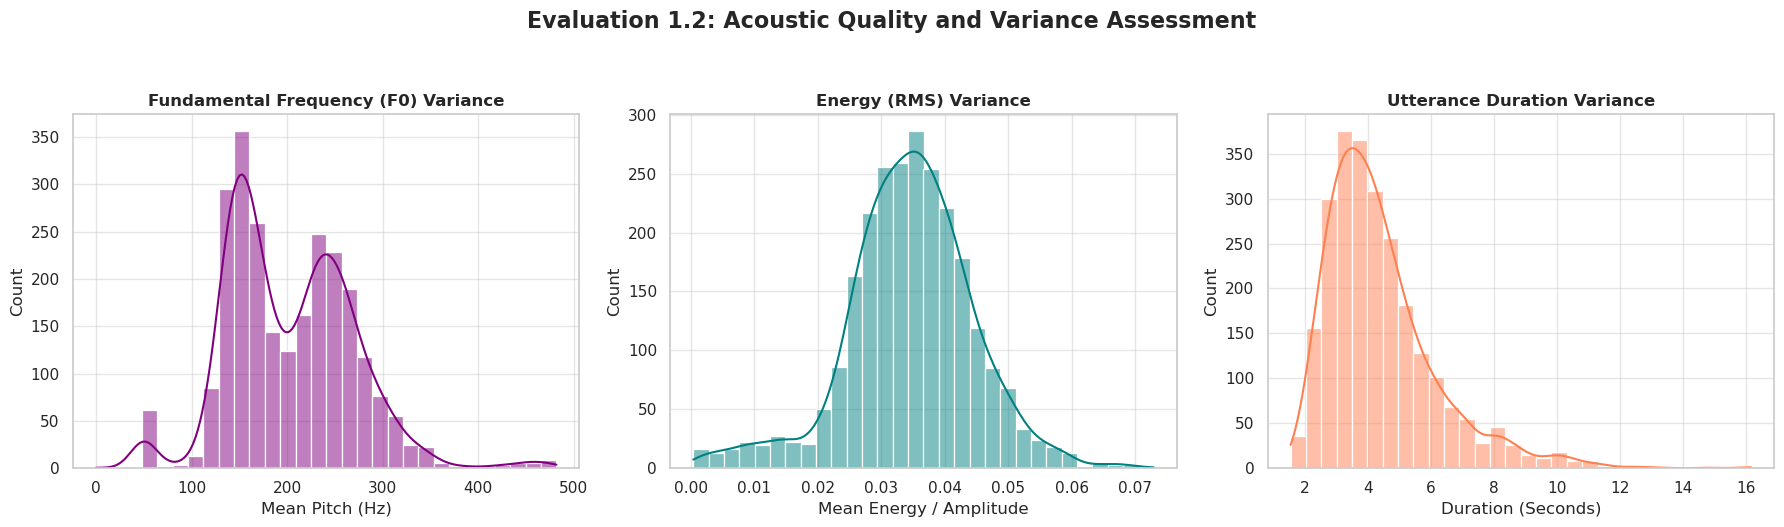

In [3]:
plot_acoustic_variance(evaluate_acoustic_variance("./data/synthesized_train"))

Randomly sampled 2500 files for F0 extraction.
Starting multiprocessing pool...


Extracting Acoustic Features: 100%|██████████| 2500/2500 [08:30<00:00,  4.90it/s]



--- Acoustic Variance Metrics ---
Goal: High standard deviation across the dataset indicates successful conditional synthesis.
Dataset Pitch (F0) Std. Dev:   65.63 Hz (PASS: High variance)
Dataset Energy (RMS) Std. Dev: 0.0100 (PASS: Volume variation detected)
Dataset Duration Std. Dev:     1.82 sec


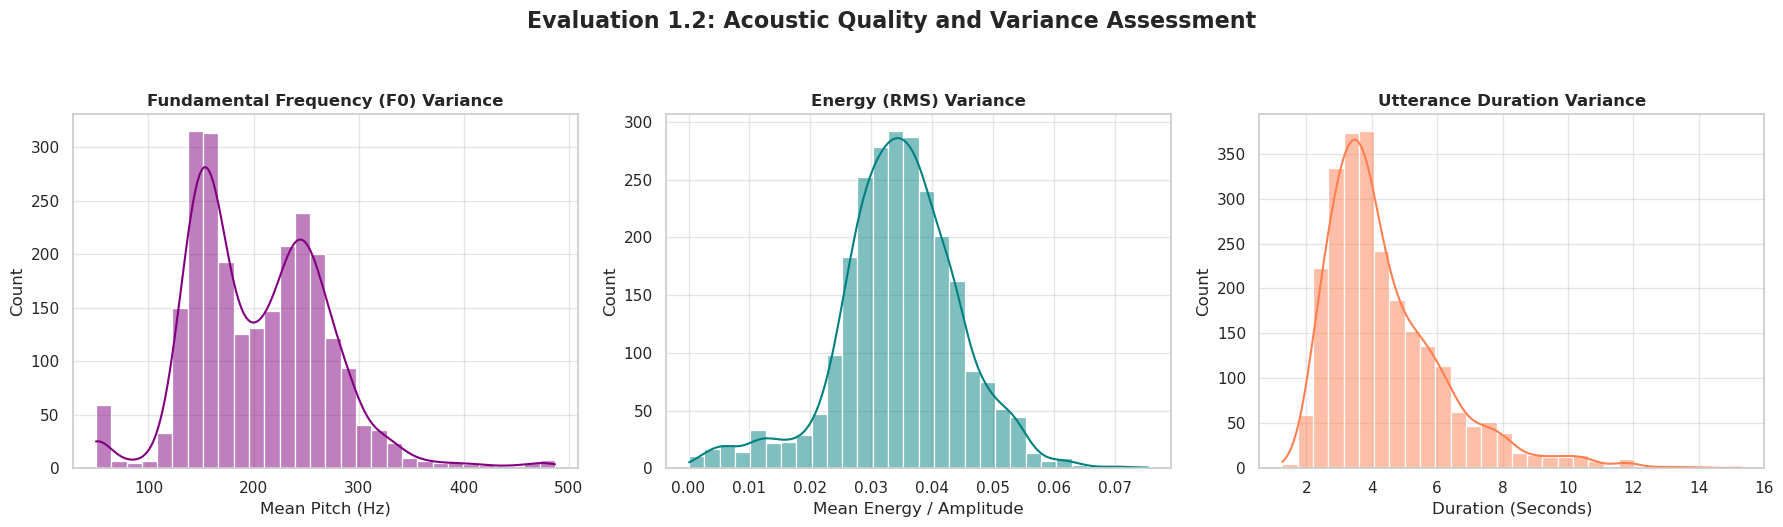

In [4]:
plot_acoustic_variance(evaluate_acoustic_variance("./data/synthesized_test"))